# 6. Análise de Associação e Detecção de Outliers

## Introdução

Nesta etapa serão aplicadas técnicas de aprendizagem não supervisionada para identificar padrões ocultos e observações atípicas no conjunto de dados.

Serão utilizadas:

- Análise de Associação utilizando o algoritmo Apriori.
- Detecção de Outliers utilizando o algoritmo Local Outlier Factor (LOF).

O objetivo é complementar as análises realizadas anteriormente e obter uma melhor compreensão das características dos imóveis.

In [1]:
# importando bibliotecas

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from mlxtend.frequent_patterns import apriori, association_rules
from sklearn.neighbors import LocalOutlierFactor

pd.set_option('display.max_columns', None)
pd.options.display.float_format = '{:.2f}'.format

In [2]:
# carregando os dados

df = pd.read_csv('train.csv')

print(df.shape)
df.head()

(1460, 81)


,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,LotConfig,LandSlope,Neighborhood,Condition1,Condition2,BldgType,HouseStyle,OverallQual,OverallCond,YearBuilt,YearRemodAdd,RoofStyle,RoofMatl,Exterior1st,Exterior2nd,MasVnrType,MasVnrArea,ExterQual,ExterCond,Foundation,BsmtQual,BsmtCond,BsmtExposure,BsmtFinType1,BsmtFinSF1,BsmtFinType2,BsmtFinSF2,BsmtUnfSF,TotalBsmtSF,Heating,HeatingQC,CentralAir,Electrical,1stFlrSF,2ndFlrSF,LowQualFinSF,GrLivArea,BsmtFullBath,BsmtHalfBath,FullBath,HalfBath,BedroomAbvGr,KitchenAbvGr,KitchenQual,TotRmsAbvGrd,Functional,Fireplaces,FireplaceQu,GarageType,GarageYrBlt,GarageFinish,GarageCars,GarageArea,GarageQual,GarageCond,PavedDrive,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.00,8450,Pave,NaN,Reg,Lvl,AllPub,Inside,Gtl,CollgCr,Norm,Norm,1Fam,2Story,7,5,2003,2003,Gable,CompShg,VinylSd,VinylSd,BrkFace,196.00,Gd,TA,PConc,Gd,TA,No,GLQ,706,Unf,0,150,856,GasA,Ex,Y,SBrkr,856,854,0,1710,1,0,2,1,3,1,Gd,8,Typ,0,NaN,Attchd,2003.00,RFn,2,548,TA,TA,Y,0,61,0,0,0,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.00,9600,Pave,NaN,Reg,Lvl,AllPub,FR2,Gtl,Veenker,Feedr,Norm,1Fam,1Story,6,8,1976,1976,Gable,CompShg,MetalSd,MetalSd,NaN,0.00,TA,TA,CBlock,Gd,TA,Gd,ALQ,978,Unf,0,284,1262,GasA,Ex,Y,SBrkr,1262,0,0,1262,0,1,2,0,3,1,TA,6,Typ,1,TA,Attchd,1976.00,RFn,2,460,TA,TA,Y,298,0,0,0,0,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.00,11250,Pave,NaN,IR1,Lvl,AllPub,Inside,Gtl,CollgCr,Norm,Norm,1Fam,2Story,7,5,2001,2002,Gable,CompShg,VinylSd,VinylSd,BrkFace,162.00,Gd,TA,PConc,Gd,TA,Mn,GLQ,486,Unf,0,434,920,GasA,Ex,Y,SBrkr,920,866,0,1786,1,0,2,1,3,1,Gd,6,Typ,1,TA,Attchd,2001.00,RFn,2,608,TA,TA,Y,0,42,0,0,0,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.00,9550,Pave,NaN,IR1,Lvl,AllPub,Corner,Gtl,Crawfor,Norm,Norm,1Fam,2Story,7,5,1915,1970,Gable,CompShg,Wd Sdng,Wd Shng,NaN,0.00,TA,TA,BrkTil,TA,Gd,No,ALQ,216,Unf,0,540,756,GasA,Gd,Y,SBrkr,961,756,0,1717,1,0,1,0,3,1,Gd,7,Typ,1,Gd,Detchd,1998.00,Unf,3,642,TA,TA,Y,0,35,272,0,0,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.00,14260,Pave,NaN,IR1,Lvl,AllPub,FR2,Gtl,NoRidge,Norm,Norm,1Fam,2Story,8,5,2000,2000,Gable,CompShg,VinylSd,VinylSd,BrkFace,350.00,Gd,TA,PConc,Gd,TA,Av,GLQ,655,Unf,0,490,1145,GasA,Ex,Y,SBrkr,1145,1053,0,2198,1,0,2,1,4,1,Gd,9,Typ,1,TA,Attchd,2000.00,RFn,3,836,TA,TA,Y,192,84,0,0,0,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


In [3]:
# criando algumas features utilizadas no projeto

df['TotalArea'] = (
    df['GrLivArea']
    + df['TotalBsmtSF']
)

# transformando KitchenQual em valores numericos

mapeamento = {
    'Ex': 4,
    'Gd': 3,
    'TA': 2,
    'Fa': 1
}

df['KitchenQual'] = (
    df['KitchenQual']
    .replace(mapeamento)
)

df['KitchenQual'] = (
    df['KitchenQual']
    .fillna(1)
)

C:\Users\Gabriel\AppData\Local\Temp\ipykernel_18608\1665650803.py:19: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  .replace(mapeamento)


## 6.1 Análise de Associação (Apriori)

O algoritmo Apriori será utilizado para identificar relações frequentes entre características dos imóveis.

Para isso, algumas variáveis serão transformadas em categorias booleanas, facilitando a descoberta de padrões de associação.

In [4]:
# preparando os dados para o apriori

dados_apriori = pd.DataFrame()

dados_apriori['preco_alto'] = (
    df['SalePrice']
    > df['SalePrice'].median()
)

dados_apriori['alta_qualidade'] = (
    df['OverallQual']
    >= 7
)

dados_apriori['area_grande'] = (
    df['TotalArea']
    > df['TotalArea'].median()
)

dados_apriori['boa_cozinha'] = (
    df['KitchenQual']
    >= 3
)

dados_apriori['garagem_grande'] = (
    df['GarageCars']
    >= 2
)

In [5]:
# executando o algoritmo apriori

itemsets = apriori(
    dados_apriori,
    min_support=0.10,
    use_colnames=True
)

regras = association_rules(
    itemsets,
    metric='confidence',
    min_threshold=0.60
)

print('principais regras encontradas:')
display(
    regras[
        [
            'antecedents',
            'consequents',
            'support',
            'confidence',
            'lift'
        ]
    ]
    .sort_values(
        by='lift',
        ascending=False
    )
    .head(10)
)

principais regras encontradas:


,antecedents,consequents,support,confidence,lift
138,"(area_grande, garagem_grande, boa_cozinha)","(preco_alto, alta_qualidade)",0.27,0.84,2.44
152,"(preco_alto, alta_qualidade)","(area_grande, garagem_grande, boa_cozinha)",0.27,0.80,2.44
149,"(area_grande, boa_cozinha)","(preco_alto, garagem_grande, alta_qualidade)",0.27,0.80,2.39
142,"(preco_alto, garagem_grande, alta_qualidade)","(area_grande, boa_cozinha)",0.27,0.81,2.39
78,"(preco_alto, alta_qualidade)","(area_grande, boa_cozinha)",0.28,0.80,2.36
77,"(area_grande, boa_cozinha)","(preco_alto, alta_qualidade)",0.28,0.81,2.36
140,"(area_grande, preco_alto, boa_cozinha)","(garagem_grande, alta_qualidade)",0.27,0.84,2.33
150,"(garagem_grande, alta_qualidade)","(area_grande, preco_alto, boa_cozinha)",0.27,0.76,2.33
153,"(preco_alto, boa_cozinha)","(area_grande, garagem_grande, alta_qualidade)",0.27,0.72,2.33
137,"(area_grande, garagem_grande, alta_qualidade)","(preco_alto, boa_cozinha)",0.27,0.89,2.33


### Interpretação dos Resultados

As regras de associação identificadas pelo algoritmo Apriori mostraram padrões consistentes entre as características dos imóveis e seus preços de venda.

A regra mais relevante encontrada indicou que imóveis com área grande, garagem grande e boa qualidade de cozinha apresentam aproximadamente 84% de confiança para também pertencerem às categorias de preço alto e alta qualidade construtiva.

Além disso, diversas regras apresentaram valores de lift superiores a 2,0, indicando associações fortes entre as variáveis analisadas. Isso significa que características como área ampla, boa infraestrutura e elevada qualidade construtiva tendem a ocorrer juntas com maior frequência do que seria esperado ao acaso.

Os resultados confirmam que imóveis maiores e com melhor padrão de construção possuem forte relação com preços mais elevados, reforçando as conclusões obtidas nas etapas anteriores do projeto.

## 6.2 Análise de Outliers (Local Outlier Factor)

Nesta etapa será utilizado o algoritmo Local Outlier Factor (LOF) para identificar imóveis com características incomuns em relação ao restante do conjunto de dados.

Esses imóveis podem representar casos excepcionais, erros de registro ou propriedades com características muito diferentes da média.

In [7]:
# selecionando variaveis numericas

colunas_lof = [
    'SalePrice',
    'GrLivArea',
    'OverallQual',
    'GarageCars',
    'TotalArea'
]

dados_lof = df[colunas_lof].fillna(0)

In [8]:
# aplicando local outlier factor

lof = LocalOutlierFactor(
    n_neighbors=20,
    contamination=0.05
)

outliers = lof.fit_predict(dados_lof)

df['outlier'] = outliers

print('quantidade de observacoes normais:')
print((df['outlier'] == 1).sum())

print()

print('quantidade de outliers:')
print((df['outlier'] == -1).sum())

quantidade de observacoes normais:
1387

quantidade de outliers:
73


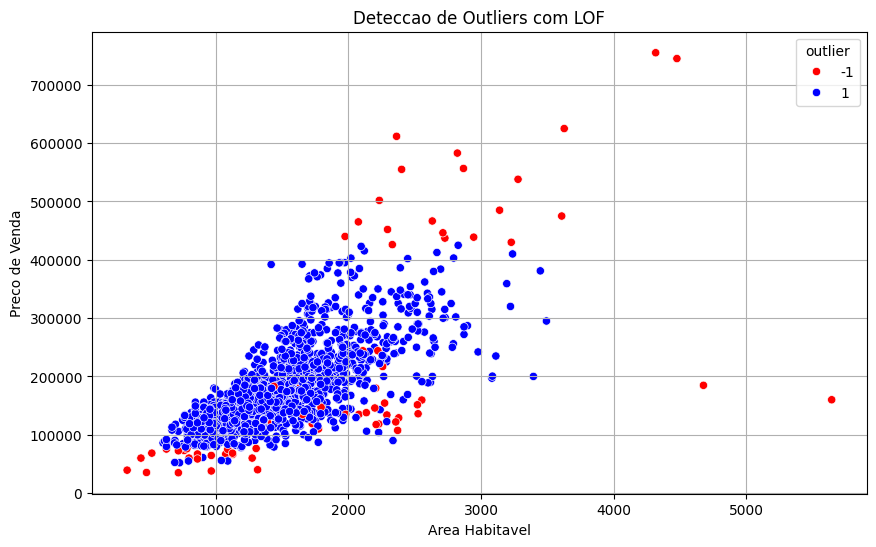

In [9]:
plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=df,
    x='GrLivArea',
    y='SalePrice',
    hue='outlier',
    palette={
        1: 'blue',
        -1: 'red'
    }
)

plt.title('Deteccao de Outliers com LOF')
plt.xlabel('Area Habitavel')
plt.ylabel('Preco de Venda')
plt.grid(True)

plt.show()

In [10]:
print('exemplos de outliers encontrados:')

display(
    df[df['outlier'] == -1][
        [
            'SalePrice',
            'GrLivArea',
            'OverallQual',
            'GarageCars'
        ]
    ].head(10)
)

exemplos de outliers encontrados:


,SalePrice,GrLivArea,OverallQual,GarageCars
1,181500,1262,6,2
29,68500,520,4,1
30,40000,1317,4,1
58,438780,2945,10,3
66,180000,2207,7,2
70,244000,2223,7,2
93,133900,2291,6,2
113,217000,2259,6,2
144,125000,1728,5,2
178,501837,2234,9,3
